# 2. Data Quality, Validation, and Visual Exploration

**Objective:** Evaluate completeness, consistency, and accuracy; detect bias, imbalance, and noise; explain findings with visualisations.

**Deliverables:** Plots in `reports/figures/`, summary table in `reports/tables/data_quality_summary.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_RAW = ROOT / "data" / "raw" / "zoopla_raw.csv"
FIG_DIR = ROOT / "reports" / "figures"
TABLE_DIR = ROOT / "reports" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_RAW)
print("Loaded rows:", len(df))

Loaded rows: 14438


## 2.1 Dataset Summary

Using `df.info()` and `df.describe()` to capture column names, dtypes, non-null counts, and example statistics.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14438 entries, 0 to 14437
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             14438 non-null  int64
 1   url            14438 non-null  str  
 2   city           14438 non-null  str  
 3   price          14438 non-null  int64
 4   address        14438 non-null  str  
 5   property_type  14438 non-null  str  
 6   bedrooms       14438 non-null  int64
 7   bathrooms      14438 non-null  int64
 8   living_rooms   14438 non-null  int64
 9   area_sqft      14438 non-null  int64
 10  description    14438 non-null  str  
 11  created_at     14438 non-null  str  
 12  epc_rating     11406 non-null  str  
dtypes: int64(6), str(7)
memory usage: 1.4 MB


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,14438.0,NaN,NaN,NaN,12343.075357,6917.496972,1.0,6302.25,12671.5,18413.75,23303.0
url,14438,14438,https://www.zoopla.co.uk/for-sale/details/7208...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,14438,19,West Yorkshire,1877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,14438.0,NaN,NaN,NaN,329059.692617,413181.461406,4000.0,174950.0,250000.0,375000.0,27500000.0
address,14438,12367,"Parliament Square, Liverpool City Centre, Live...",20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_type,14438,7,Flat/Apartment,4802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,14438.0,NaN,NaN,NaN,2.677241,1.396518,0.0,2.0,3.0,3.0,66.0
bathrooms,14438.0,NaN,NaN,NaN,1.447223,1.080255,0.0,1.0,1.0,2.0,82.0
living_rooms,14438.0,NaN,NaN,NaN,1.369996,0.802412,0.0,1.0,1.0,2.0,21.0
area_sqft,14438.0,NaN,NaN,NaN,369.832525,1405.470704,0.0,0.0,0.0,592.0,87273.0


In [4]:
# Build summary table: column, dtype, non_null, null_pct, example values
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null": df.count().values,
    "null_count": df.isna().sum().values,
})
summary["null_pct"] = (summary["null_count"] / len(df) * 100).round(2)
summary["example"] = df.iloc[0].astype(str).values
summary.to_csv(TABLE_DIR / "data_quality_summary.csv", index=False)
summary

,column,dtype,non_null,null_count,null_pct,example
0,id,int64,14438,0,0.0,1
1,url,str,14438,0,0.0,https://www.zoopla.co.uk/for-sale/details/7208...
2,city,str,14438,0,0.0,London
3,price,int64,14438,0,0.0,600000
4,address,str,14438,0,0.0,"South Park Hill Road, South Croydon CR2"
5,property_type,str,14438,0,0.0,Flat/Apartment
6,bedrooms,int64,14438,0,0.0,3
7,bathrooms,int64,14438,0,0.0,3
8,living_rooms,int64,14438,0,0.0,1
9,area_sqft,int64,14438,0,0.0,0


## 2.2 Missing Values Analysis

**Interpretation:** Missing `epc_rating` often occurs because agents did not upload EPC certificates. Missing `area_sqft` can stem from listing types (e.g. land, commercial) or agents not providing floor area. We visualise missingness and document possible causes.

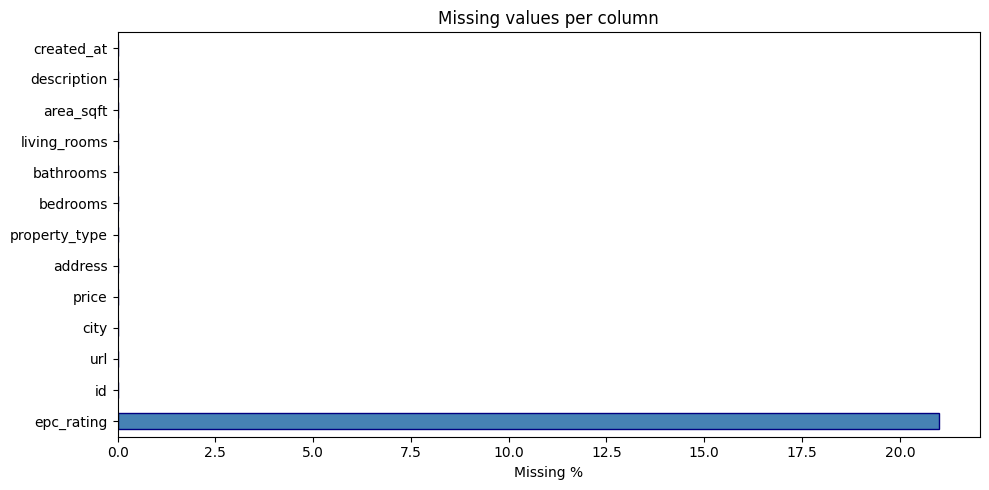

In [5]:
# Missing percentage per column
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
missing_pct.plot(kind="barh", ax=ax, color="steelblue", edgecolor="navy")
ax.set_xlabel("Missing %")
ax.set_title("Missing values per column")
plt.tight_layout()
plt.savefig(FIG_DIR / "missing_pct_bar.png", dpi=150, bbox_inches="tight")
plt.show()

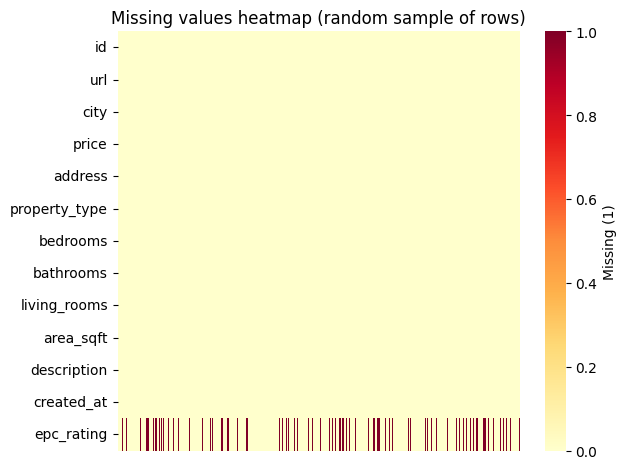

In [6]:
# Missingness heatmap (sample of rows to keep plot readable)
n_sample = min(500, len(df))
np.random.seed(42)
idx = np.random.choice(df.index, size=n_sample, replace=False)
mask = df.loc[idx].isna().astype(int)
sns.heatmap(mask.T, cmap="YlOrRd", cbar_kws={"label": "Missing (1)"}, xticklabels=False, yticklabels=df.columns)
plt.title("Missing values heatmap (random sample of rows)")
plt.tight_layout()
plt.savefig(FIG_DIR / "missing_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.3 Value Consistency & Type Checks

- **Price:** Should be numeric; check for currency symbols or invalid values.
- **Bedrooms/bathrooms:** Numeric consistency and plausible ranges.
- **EPC rating:** Standardise to A–G scale (uppercase).

In [7]:
# Price: ensure numeric (strip £ and commas if present)
price_orig = df["price"].astype(str)
non_numeric = price_orig.str.replace(r"[\d,\.]", "", regex=True).str.strip()
non_numeric = non_numeric[non_numeric != ""]
print("Price: non-numeric-like values (sample):", non_numeric.head(10).tolist())
# Bedrooms/bathrooms
for col in ["bedrooms", "bathrooms"]:
    if col in df.columns:
        print(f"{col} unique:", sorted(df[col].dropna().unique())[:20])
# EPC
if "epc_rating" in df.columns:
    print("epc_rating unique:", df["epc_rating"].dropna().unique())

Price: non-numeric-like values (sample): []
bedrooms unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(15), np.int64(16), np.int64(18), np.int64(19), np.int64(26), np.int64(30), np.int64(34)]
bathrooms unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(19), np.int64(21), np.int64(82)]
epc_rating unique: <StringArray>
['B', 'C', 'D', 'E', 'A', 'G', 'F']
Length: 7, dtype: str


## 2.4 Distribution Analysis

Distributions for price (normal and log scale), bedrooms, bathrooms, area_sqft, property_type counts, and top 10 cities.

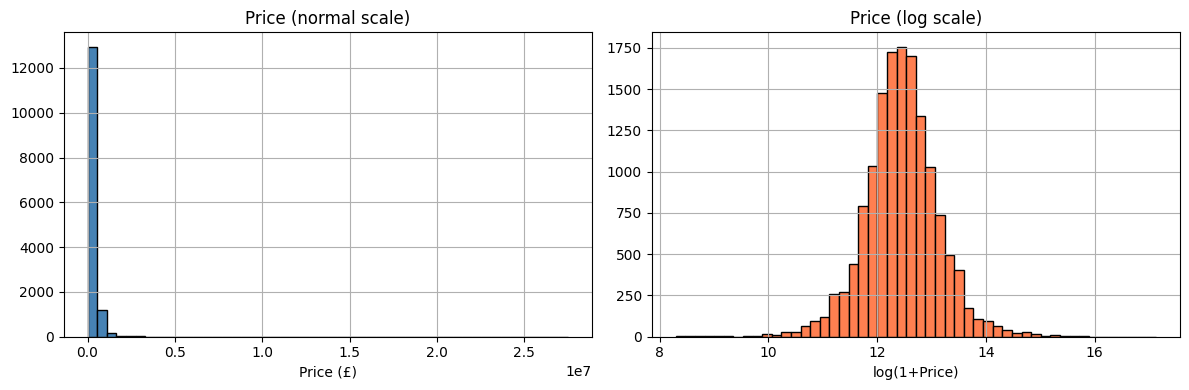

In [8]:
# Price: numeric for plotting (handle if stored as string with £)
price_series = pd.to_numeric(df["price"].astype(str).str.replace(r"[\£,]", "", regex=True), errors="coerce")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
price_series.dropna().hist(ax=axes[0], bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("Price (normal scale)")
axes[0].set_xlabel("Price (£)")
np.log1p(price_series.dropna()).hist(ax=axes[1], bins=50, color="coral", edgecolor="black")
axes[1].set_title("Price (log scale)")
axes[1].set_xlabel("log(1+Price)")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

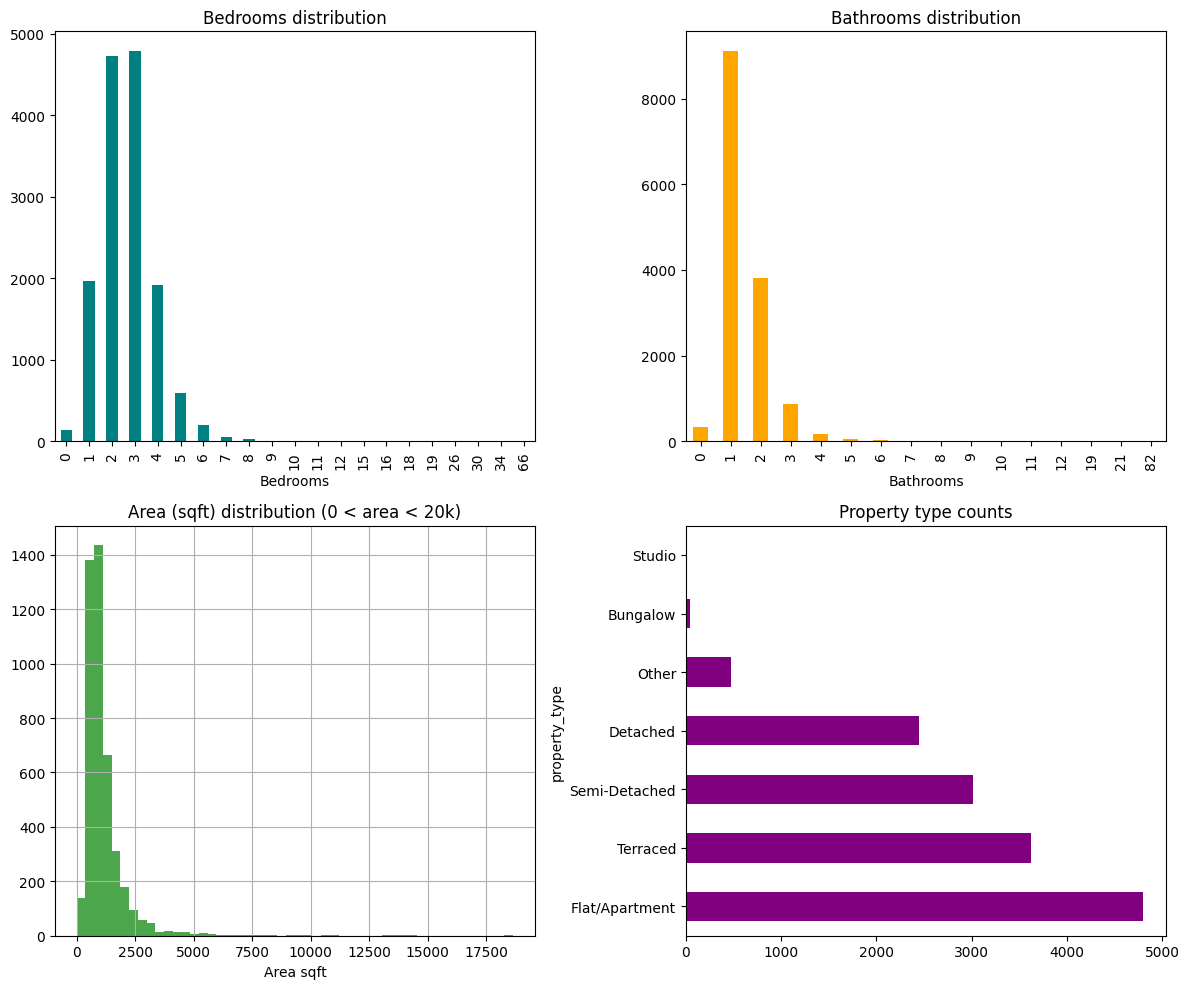

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Bedrooms
df["bedrooms"].value_counts().sort_index().plot(kind="bar", ax=axes[0,0], color="teal")
axes[0,0].set_title("Bedrooms distribution")
axes[0,0].set_xlabel("Bedrooms")
# Bathrooms
df["bathrooms"].value_counts().sort_index().plot(kind="bar", ax=axes[0,1], color="orange")
axes[0,1].set_title("Bathrooms distribution")
axes[0,1].set_xlabel("Bathrooms")
# area_sqft (exclude 0 for clearer distribution)
area = pd.to_numeric(df["area_sqft"], errors="coerce")
area_positive = area[(area > 0) & (area < 20000)]
area_positive.hist(ax=axes[1,0], bins=50, color="green", alpha=0.7)
axes[1,0].set_title("Area (sqft) distribution (0 < area < 20k)")
axes[1,0].set_xlabel("Area sqft")
# property_type
df["property_type"].value_counts().plot(kind="barh", ax=axes[1,1], color="purple")
axes[1,1].set_title("Property type counts")
plt.tight_layout()
plt.savefig(FIG_DIR / "distributions_beds_baths_area_type.png", dpi=150, bbox_inches="tight")
plt.show()

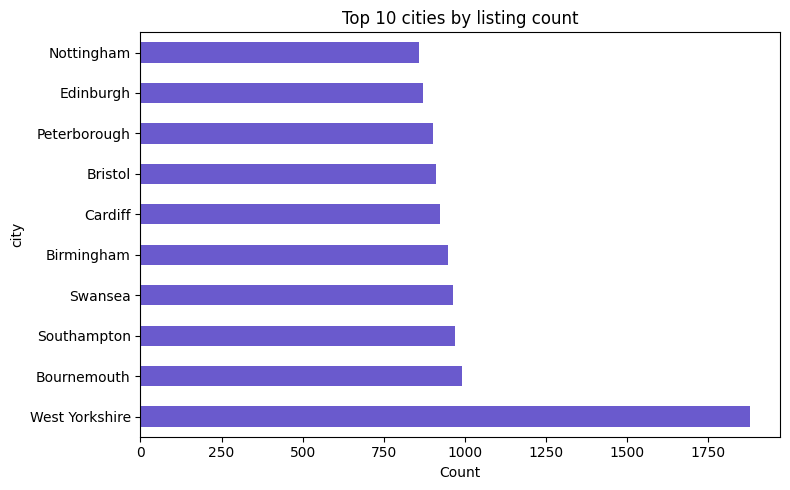

In [10]:
# Top 10 cities
city_counts = df["city"].value_counts().head(10)
city_counts.plot(kind="barh", figsize=(8, 5), color="slateblue")
plt.title("Top 10 cities by listing count")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "top10_cities.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.5 Geographic Bias

Listings per city and boxplot of price by city show geographic imbalance: e.g. London may dominate, affecting model generalisation. We document this for Responsible AI and mitigation (e.g. stratification by city).

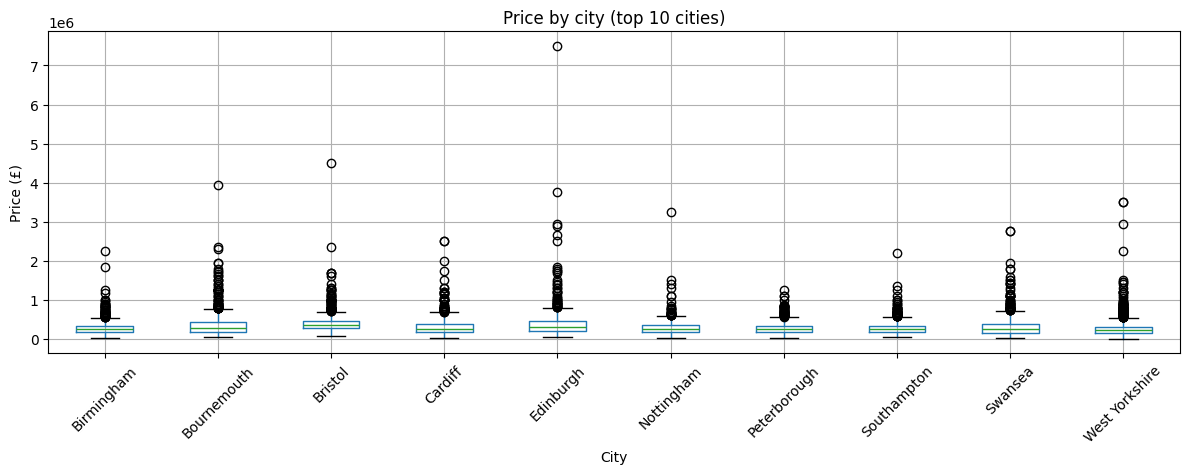

In [11]:
# Boxplot: price by city (top cities only to avoid clutter)
top_cities = df["city"].value_counts().head(10).index.tolist()
df_top = df[df["city"].isin(top_cities)].copy()
df_top["price_num"] = pd.to_numeric(df_top["price"].astype(str).str.replace(r"[\£,]", "", regex=True), errors="coerce")
df_top = df_top.dropna(subset=["price_num"])
fig, ax = plt.subplots(figsize=(12, 5))
df_top.boxplot(column="price_num", by="city", ax=ax, rot=45)
ax.set_title("Price by city (top 10 cities)")
ax.set_xlabel("City")
ax.set_ylabel("Price (£)")
plt.suptitle("")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_by_city_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.6 Outlier Detection

Using boxplots and IQR rule for price and area. Extreme records are inspected to define a handling strategy (e.g. winsorise or exclude in modelling).

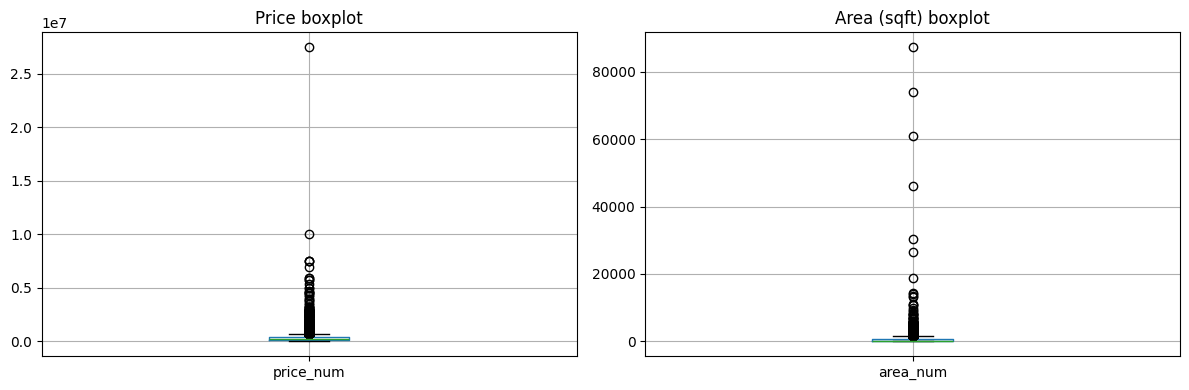

Price: Q1=174950, Q3=375000, IQR=200050; outside [-125125, 675075] -> 948 outliers
Area: Q1=0, Q3=592, IQR=592; outside [-888, 1480] -> 814 outliers


In [12]:
# Numeric columns for outlier check
df_plot = df.copy()
df_plot["price_num"] = pd.to_numeric(df_plot["price"].astype(str).str.replace(r"[\£,]", "", regex=True), errors="coerce")
df_plot["area_num"] = pd.to_numeric(df_plot["area_sqft"], errors="coerce")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_plot[["price_num"]].boxplot(ax=axes[0])
axes[0].set_title("Price boxplot")
df_plot[["area_num"]].boxplot(ax=axes[1])
axes[1].set_title("Area (sqft) boxplot")
plt.tight_layout()
plt.savefig(FIG_DIR / "outliers_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
# IQR rule
for col, name in [("price_num", "Price"), ("area_num", "Area")]:
    q1, q3 = df_plot[col].quantile(0.25), df_plot[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_plot[col] < lo) | (df_plot[col] > hi)).sum()
    print(f"{name}: Q1={q1:.0f}, Q3={q3:.0f}, IQR={iqr:.0f}; outside [{(lo):.0f}, {(hi):.0f}] -> {n_out} outliers")

## 2.7 Correlation Analysis

Correlation matrix for numeric features and scatter plots (price vs area, price vs bedrooms) to inform feature selection and detect collinearity.

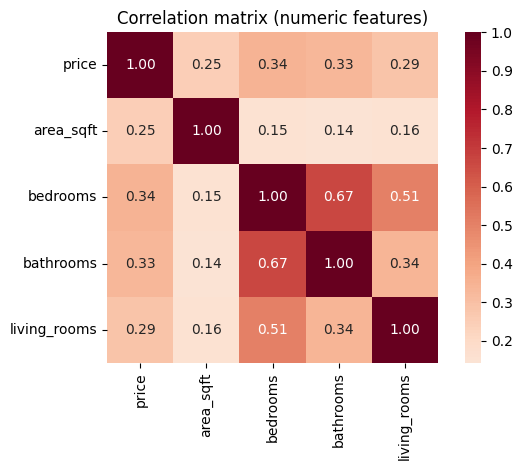

In [13]:
# Numeric subset
num_cols = ["price_num", "area_num", "bedrooms", "bathrooms"]
if "living_rooms" in df_plot.columns:
    num_cols.append("living_rooms")
df_corr = df_plot[num_cols].dropna(how="all")
df_corr = df_corr.rename(columns={"price_num": "price", "area_num": "area_sqft"})
corr = df_corr.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

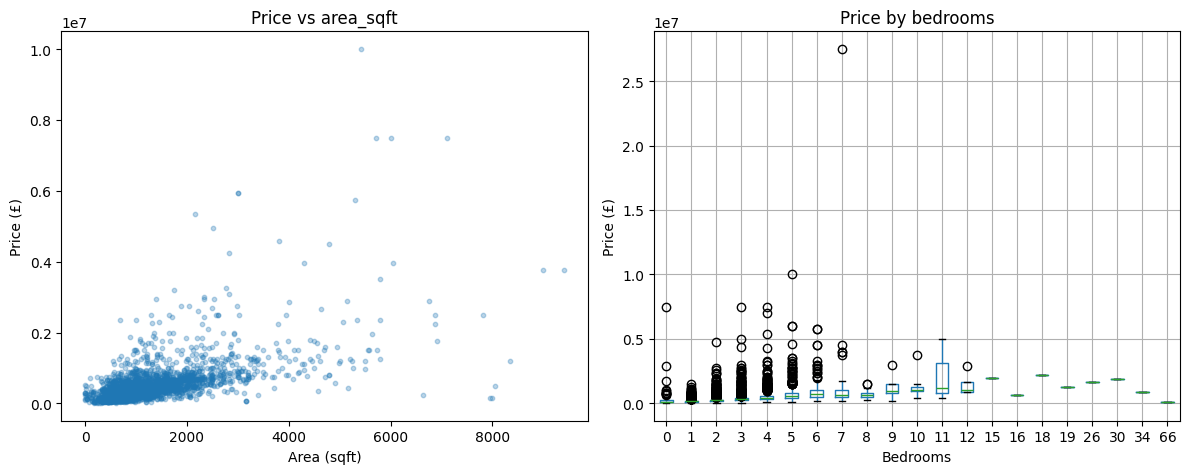

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Price vs area (exclude zeros and extreme area)
sub = df_plot[(df_plot["area_num"] > 0) & (df_plot["area_num"] < 10000)].dropna(subset=["price_num", "area_num"])
axes[0].scatter(sub["area_num"], sub["price_num"], alpha=0.3, s=10)
axes[0].set_xlabel("Area (sqft)")
axes[0].set_ylabel("Price (£)")
axes[0].set_title("Price vs area_sqft")
# Price vs bedrooms
df_plot.dropna(subset=["price_num", "bedrooms"]).boxplot(column="price_num", by="bedrooms", ax=axes[1])
axes[1].set_xlabel("Bedrooms")
axes[1].set_ylabel("Price (£)")
axes[1].set_title("Price by bedrooms")
plt.suptitle("")
plt.tight_layout()
plt.savefig(FIG_DIR / "scatter_price_area_bedrooms.png", dpi=150, bbox_inches="tight")
plt.show()